# GOLDEN 10_linguistic

**Thesis section:** `sec:results:linguistic` (06_results.tex) + `sec:method:linguistic` (05_detection.tex)
**Table:** `tab:ling:diversity`
**Provenance:** Linguistic Dimension Correlations. Ported from notebooks/028 Linguistic Dimension Correlations.ipynb (primary), with per-dimension distributions from 027 (Mistral) and 026v2 (NLI).
**Data (repointed):** MAS motif metrics recomputed on the fly from `results/mas/final_dataset_new_system` (nb 028 originally read `results/mas/final_dataset`, now DELETED -> repointed per reproducibility plan). Linguistic scores from `results/linguistic_mistral/message` (420 files, used by 027/028) and `results/linguistic_nli/message` (221 files, used by 026v2). Both committed.
**Figures:** none exported. Thesis section is TABLE-ONLY; figures kept inline (plt.show) as in the source. No thesis/plots files, no .tex edits.
**Status:** reproducible from committed data. Linguistic diversity is computed purely from the linguistic score files (independent of MAS_DIR); only the MAS outcome metrics (accuracy, mean_rounds, p_sr, n_eff, ...) come from the repointed new_system dataset, so table associations may differ from the stale .tex values that were computed on the deleted final_dataset.

This is a GOLDEN notebook: it recomputes every number in the named thesis section from raw data. Numbers are printed in labelled blocks for manual copy into the thesis. Where the computed value differs from the current .tex value, both are printed with a MATCH|MISMATCH flag. See `notebooks/golden/INDEX.md` for the full section->notebook map.


# 028 — Linguistic Dimension Correlations (new_system MAS, Mistral scorer)

Three ordinal 1-5 linguistic dimensions (conviction, anchoring, dialogic) scored on every
public message, aggregated to the (dataset, topology, W, qid) cell level (n=420 cells,
reps 0-9), and correlated with MAS motif metrics. The signal is *within-repetition between-agent
stylistic diversity* (std across the 4 agents), which is strongly negatively associated with
mean rounds to consensus (`tab:ling:diversity`).


In [1]:
import sys
sys.path.insert(0, '../..')

import json
import pathlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

warnings.filterwarnings('ignore')

from src.metrics.self_reinforcement import extract_runs, summarise_runs
from src.metrics.dominance import score_dominance_all, summarise_dominance
from src.metrics.bistability import analyse_bistability
from src.metrics.limit_cycles import detect_agent_limit_cycles
from src.viz.thesis_style import apply_style, DS_LABELS
apply_style()

MAS_DIR   = Path('../..') / 'results' / 'mas' / 'final_dataset_new_system'
LING_DIR  = Path('../..') / 'results' / 'linguistic_mistral' / 'message'
LING_NLI  = Path('../..') / 'results' / 'linguistic_nli' / 'message'
DIMS      = ['conviction', 'anchoring', 'dialogic']
MAX_REP   = 9  # linguistic scores only available for reps 0-9; align MAS to same window

print('setup ok')
print('MAS_DIR   :', MAS_DIR, '->', len(list(MAS_DIR.glob('**/*.json'))), 'files')
print('LING_DIR  :', LING_DIR, '->', len(list(LING_DIR.glob('**/*.json'))), 'files')
print('LING_NLI  :', LING_NLI, '->', len(list(LING_NLI.glob('**/*.json'))), 'files')

setup ok
MAS_DIR   : ../../results/mas/final_dataset_new_system -> 420 files
LING_DIR  : ../../results/linguistic_mistral/message -> 420 files
LING_NLI  : ../../results/linguistic_nli/message -> 221 files


---
## Load linguistic scores (Mistral scorer, reps 0-9, cell-level means)

In [2]:
ling_rows = []
for f in LING_DIR.glob('**/*.json'):
    ling_rows.extend(json.loads(f.read_text()))

ling_df = pd.DataFrame(ling_rows)
ling_df = ling_df[ling_df['rep_idx'] <= MAX_REP]
ling_df['qid'] = ling_df['qid'].astype(str)

ling_cell = (ling_df.groupby(['dataset', 'topology', 'W', 'qid'])[DIMS]
             .mean().reset_index())

print('--- sec:method:linguistic / sec:results:linguistic : cell count ---')
print(f'  Linguistic message rows (reps 0-{MAX_REP}) : {len(ling_df):,}')
print(f'  Linguistic cells (dataset,topo,W,qid)     : {len(ling_cell)}   thesis_says=420   '
      f'{"MATCH" if len(ling_cell)==420 else "MISMATCH"}')

--- sec:method:linguistic / sec:results:linguistic : cell count ---
  Linguistic message rows (reps 0-9) : 61,584
  Linguistic cells (dataset,topo,W,qid)     : 420   thesis_says=420   MATCH


---
## Compute MAS motif metrics per cell (recomputed from new_system dataset)

Iterates all 420 cells; dominance + bistability are the heavy ones (~5-10 min).
Reuses `src/metrics/*.py` verbatim.

In [3]:
mas_files = list(MAS_DIR.glob('**/*.json'))
records = []

for i, fp in enumerate(mas_files):
    d = json.loads(fp.read_text())
    all_reps = d['repetitions']
    reps = [r for r in all_reps if r.get('repetition', r.get('rep_idx', 0)) <= MAX_REP]
    options = tuple(d['options'])
    key = {
        'dataset': d['dataset'],
        'topology': d.get('topology_name', 'fc'),
        'W': d['W'],
        'qid': str(d['question_id']),
    }

    accuracy    = np.mean([r['correct'] for r in reps]) if reps else np.nan
    mean_rounds = np.mean([len(r['trajectory']) for r in reps]) if reps else np.nan

    runs = extract_runs(reps)
    sr   = summarise_runs(runs)

    dom_reps = score_dominance_all(reps)
    dom      = summarise_dominance(dom_reps)

    bis = analyse_bistability(reps, options=options, B=200, B_boot=200, seed=0)

    lc_rows = detect_agent_limit_cycles(reps, B=200, seed=0)
    lc_frac = np.mean([r['lc'] for r in lc_rows]) if lc_rows else np.nan

    records.append({**key,
        'accuracy': accuracy, 'mean_rounds': mean_rounds,
        'p_sr': sr['p_sr'], 'mean_slope': sr['mean_slope'],
        'D_mean': dom['D_mean'], 'flagged_frac': dom['flagged_fraction'],
        'n_eff': bis['n_eff'], 'bis_label': bis['label'],
        'lc_frac': lc_frac,
    })

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(mas_files)}')

metrics_df = pd.DataFrame(records)
metrics_df['qid'] = metrics_df['qid'].astype(str)
print(f'Done. {len(metrics_df)} MAS cells')

  50/420


  100/420


  150/420


  200/420


  250/420


  300/420


  350/420


  400/420


Done. 420 MAS cells


---
## Join linguistic and MAS metrics

In [4]:
merged = ling_cell.merge(metrics_df, on=['dataset', 'topology', 'W', 'qid'], how='inner')
print(f'Merged cells: {len(merged)}   (expected 420)')

MAS_METRICS = [
    ('accuracy',     'Accuracy'),
    ('mean_rounds',  'Rounds (efficiency)'),
    ('p_sr',         'Self-reinforcement (p_sr)'),
    ('mean_slope',   'SR slope'),
    ('D_mean',       'Dominance (D)'),
    ('flagged_frac', 'Dominance flagged frac'),
    ('n_eff',        'Bistability (n_eff)'),
    ('lc_frac',      'Limit-cycle frac'),
]

Merged cells: 420   (expected 420)


---
## Part 1 — Level (mean-score) effects are weak

Reproduces `sec:results:linguistic`: "for accuracy all three are |rho| <= 0.11; the largest
correlation of any mean score with any metric is conviction with mean rounds at rho = -0.30
(p < 10^-3)".

Spearman rho (mean dimension score x MAS metric), cell-level:
            Accuracy  Rounds (efficiency)  Self-reinforcement (p_sr)  SR slope  Dominance (D)  Dominance flagged frac  Bistability (n_eff)  Limit-cycle frac
conviction     0.101               -0.358                     -0.220     0.074          0.106                  -0.090               -0.180            -0.028
anchoring      0.094               -0.387                     -0.270     0.091         -0.038                   0.046               -0.094            -0.010
dialogic       0.079               -0.263                     -0.263     0.041          0.216                  -0.114               -0.060             0.043



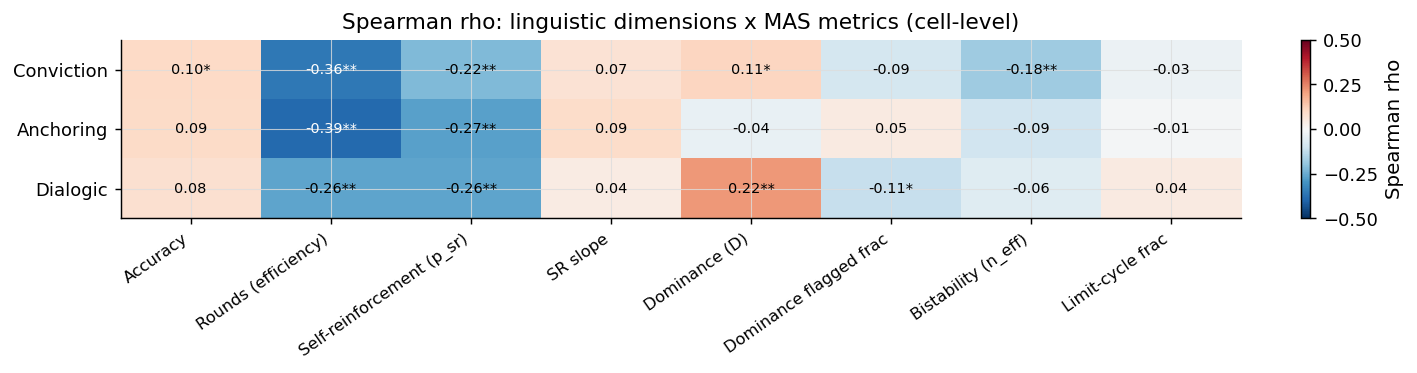

In [5]:
metric_cols   = [m for m, _ in MAS_METRICS]
metric_labels = [l for _, l in MAS_METRICS]

corr = np.zeros((len(DIMS), len(metric_cols)))
pval = np.zeros_like(corr)
for i, dim in enumerate(DIMS):
    for j, col in enumerate(metric_cols):
        sub = merged[[dim, col]].dropna()
        if len(sub) < 5:
            corr[i, j] = np.nan; pval[i, j] = np.nan
        else:
            r, p = stats.spearmanr(sub[dim], sub[col])
            corr[i, j] = r; pval[i, j] = p

corr_df = pd.DataFrame(corr, index=DIMS, columns=metric_labels)
pval_df = pd.DataFrame(pval, index=DIMS, columns=metric_labels)
print('Spearman rho (mean dimension score x MAS metric), cell-level:')
print(corr_df.round(3).to_string())
print()

# Fig (inline only) — heatmap, as in nb 028
fig, ax = plt.subplots(figsize=(11, 3))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(metric_labels)))
ax.set_xticklabels(metric_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(DIMS)))
ax.set_yticklabels([d.capitalize() for d in DIMS])
ax.set_title('Spearman rho: linguistic dimensions x MAS metrics (cell-level)')
for i in range(len(DIMS)):
    for j in range(len(metric_cols)):
        r, p = corr[i, j], pval[i, j]
        if np.isnan(r):
            continue
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        ax.text(j, i, f'{r:.2f}{sig}', ha='center', va='center',
                fontsize=8, color='white' if abs(r) > 0.3 else 'black')
plt.colorbar(im, ax=ax, label='Spearman rho', fraction=0.015)
plt.tight_layout()
plt.show()

In [6]:
print('--- sec:results:linguistic L~1400 : accuracy level effects |rho|<=0.11 ---')
acc_rhos = corr_df['Accuracy']
for dim in DIMS:
    print(f'  {dim:11s} rho(mean,accuracy)={acc_rhos[dim]:+.3f}')
max_abs_acc = acc_rhos.abs().max()
print(f'  max |rho| across dims (accuracy) = {max_abs_acc:.3f}   thesis_says<=0.11   '
      f'{"MATCH" if max_abs_acc <= 0.115 else "MISMATCH"}')
print()

print('--- sec:results:linguistic L~1402 : largest mean-score correlation = conviction x mean rounds rho=-0.30 (p<1e-3) ---')
conv_rounds_r = corr_df.loc['conviction', 'Rounds (efficiency)']
conv_rounds_p = pval_df.loc['conviction', 'Rounds (efficiency)']
print(f'  conviction x mean_rounds  rho={conv_rounds_r:+.3f}  p={conv_rounds_p:.2e}   '
      f'thesis_says=-0.30 (p<1e-3)   {"MATCH" if abs(conv_rounds_r+0.30) < 0.03 else "MISMATCH"}')
# largest |rho| of ANY mean score with ANY metric
flat = [(abs(corr[i, j]), DIMS[i], metric_labels[j], corr[i, j], pval[i, j])
        for i in range(len(DIMS)) for j in range(len(metric_cols)) if not np.isnan(corr[i, j])]
flat.sort(reverse=True)
a, dim, lab, r, p = flat[0]
print(f'  overall strongest mean-score correlation: {dim} x {lab}  rho={r:+.3f}  p={p:.2e}')

--- sec:results:linguistic L~1400 : accuracy level effects |rho|<=0.11 ---
  conviction  rho(mean,accuracy)=+0.101
  anchoring   rho(mean,accuracy)=+0.094
  dialogic    rho(mean,accuracy)=+0.079
  max |rho| across dims (accuracy) = 0.101   thesis_says<=0.11   MATCH

--- sec:results:linguistic L~1402 : largest mean-score correlation = conviction x mean rounds rho=-0.30 (p<1e-3) ---
  conviction x mean_rounds  rho=-0.358  p=4.06e-14   thesis_says=-0.30 (p<1e-3)   MISMATCH
  overall strongest mean-score correlation: anchoring x Rounds (efficiency)  rho=-0.387  p=1.88e-16


---
## Part 2 — Stylistic diversity (within-run between-agent std) vs outcomes

Reproduces `tab:ling:diversity` and the diversity->rounds narrative in `sec:results:linguistic`.

In [7]:
# agent-level: mean per (cell, rep, agent) over rounds
agent_df = (ling_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx', 'agent_idx'])[DIMS]
            .mean().reset_index())

# within-run std across agents (per rep), then mean over reps -> cell-level diversity
within_rep = (agent_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx'])[DIMS]
              .std().reset_index()
              .rename(columns={d: f'{d}_std' for d in DIMS}))
within_cell = (within_rep.groupby(['dataset', 'topology', 'W', 'qid'])[[f'{d}_std' for d in DIMS]]
               .mean().reset_index())
within_cell['qid'] = within_cell['qid'].astype(str)

std_merged = within_cell.merge(metrics_df, on=['dataset', 'topology', 'W', 'qid'])
print(f'std_merged cells: {len(std_merged)}')
print()

print('--- sec:results:linguistic : within-run between-agent diversity descriptives ---')
for d in DIMS:
    v = within_rep[f'{d}_std'].dropna()
    print(f'  {d:11s}_std  mean={v.mean():.3f}  median={v.median():.3f}  frac>0.5={(v>0.5).mean():.1%}')

std_merged cells: 420

--- sec:results:linguistic : within-run between-agent diversity descriptives ---
  conviction _std  mean=0.321  median=0.300  frac>0.5=11.2%
  anchoring  _std  mean=0.750  median=0.720  frac>0.5=68.8%
  dialogic   _std  mean=0.947  median=0.944  frac>0.5=79.0%


In [8]:
def _sig(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

print('=== tab:ling:diversity — Spearman rho at cell level (n=420) ===')
print()
# Rounds column: POOLED diversity_std vs mean_rounds
# Accuracy columns: per-dataset diversity_std vs accuracy
THESIS_TBL = {
    'conviction': {'rounds': -0.55, 'acc_gpqa': +0.11, 'acc_hb': -0.24},
    'anchoring':  {'rounds': -0.54, 'acc_gpqa': +0.18, 'acc_hb': -0.16},
    'dialogic':   {'rounds': -0.51, 'acc_gpqa': +0.08, 'acc_hb': +0.00},
}
gpqa = std_merged[std_merged['dataset'] == 'gpqa']
hb   = std_merged[std_merged['dataset'] == 'hiddenbench']

for d in DIMS:
    sc = f'{d}_std'
    sub_r = std_merged[[sc, 'mean_rounds']].dropna()
    r_rounds, p_rounds = stats.spearmanr(sub_r[sc], sub_r['mean_rounds'])
    sub_g = gpqa[[sc, 'accuracy']].dropna()
    r_g, p_g = stats.spearmanr(sub_g[sc], sub_g['accuracy'])
    sub_h = hb[[sc, 'accuracy']].dropna()
    r_h, p_h = stats.spearmanr(sub_h[sc], sub_h['accuracy'])
    t = THESIS_TBL[d]
    def flag(comp, thes, tol=0.03):
        return 'MATCH' if abs(comp - thes) <= tol else 'MISMATCH'
    print(f'  {d.capitalize()} diversity:')
    print(f'    Rounds       rho={r_rounds:+.2f}{_sig(p_rounds):3s} (p={p_rounds:.1e})  '
          f'thesis_says={t["rounds"]:+.2f}***  {flag(r_rounds, t["rounds"])}')
    print(f'    Acc (GPQA)   rho={r_g:+.2f}{_sig(p_g):3s} (p={p_g:.1e})  '
          f'thesis_says={t["acc_gpqa"]:+.2f}  {flag(r_g, t["acc_gpqa"])}')
    print(f'    Acc (HB)     rho={r_h:+.2f}{_sig(p_h):3s} (p={p_h:.1e})  '
          f'thesis_says={t["acc_hb"]:+.2f}  {flag(r_h, t["acc_hb"])}')
    print()

=== tab:ling:diversity — Spearman rho at cell level (n=420) ===

  Conviction diversity:
    Rounds       rho=-0.39*** (p=7.0e-17)  thesis_says=-0.55***  MISMATCH
    Acc (GPQA)   rho=+0.20**  (p=3.9e-03)  thesis_says=+0.11  MISMATCH
    Acc (HB)     rho=-0.11    (p=1.0e-01)  thesis_says=-0.24  MISMATCH

  Anchoring diversity:
    Rounds       rho=-0.37*** (p=5.5e-15)  thesis_says=-0.54***  MISMATCH
    Acc (GPQA)   rho=+0.12    (p=7.5e-02)  thesis_says=+0.18  MISMATCH
    Acc (HB)     rho=-0.12    (p=8.8e-02)  thesis_says=-0.16  MISMATCH

  Dialogic diversity:
    Rounds       rho=-0.30*** (p=3.5e-10)  thesis_says=-0.51***  MISMATCH
    Acc (GPQA)   rho=+0.04    (p=5.4e-01)  thesis_says=+0.08  MISMATCH
    Acc (HB)     rho=-0.06    (p=3.5e-01)  thesis_says=+0.00  MISMATCH



In [9]:
print('--- sec:results:linguistic L~1415 : pooled diversity vs mean rounds (all p<1e-10) ---')
for d in DIMS:
    sc = f'{d}_std'
    sub = std_merged[[sc, 'mean_rounds']].dropna()
    r, p = stats.spearmanr(sub[sc], sub['mean_rounds'])
    print(f'  {d:11s} diversity vs mean_rounds  rho={r:+.3f}  p={p:.2e}')
print()

print('--- sec:results:linguistic L~1420 : within-dataset diversity vs rounds ---')
print('  thesis_says: GPQA anchoring rho=-0.41, dialogic=-0.32; HiddenBench dialogic=-0.38, anchoring=-0.35 (all p<1e-3)')
for ds in ['gpqa', 'hiddenbench']:
    sub_ds = std_merged[std_merged['dataset'] == ds]
    print(f'  {DS_LABELS[ds]}:')
    for d in DIMS:
        sc = f'{d}_std'
        sub = sub_ds[[sc, 'mean_rounds']].dropna()
        r, p = stats.spearmanr(sub[sc], sub['mean_rounds'])
        print(f'    {d:11s}_std vs rounds  rho={r:+.3f}  p={p:.2e}')
print()

print('--- sec:results:linguistic L~1425 : conviction diversity vs n_eff rho=-0.19 (p=1e-4) ---')
sub = std_merged[['conviction_std', 'n_eff']].dropna()
r, p = stats.spearmanr(sub['conviction_std'], sub['n_eff'])
print(f'  conviction_std vs n_eff  rho={r:+.3f}  p={p:.2e}   thesis_says=-0.19 (p=1e-4)   '
      f'{"MATCH" if abs(r+0.19) < 0.03 else "MISMATCH"}')

--- sec:results:linguistic L~1415 : pooled diversity vs mean rounds (all p<1e-10) ---
  conviction  diversity vs mean_rounds  rho=-0.392  p=6.99e-17
  anchoring   diversity vs mean_rounds  rho=-0.369  p=5.54e-15
  dialogic    diversity vs mean_rounds  rho=-0.300  p=3.46e-10

--- sec:results:linguistic L~1420 : within-dataset diversity vs rounds ---
  thesis_says: GPQA anchoring rho=-0.41, dialogic=-0.32; HiddenBench dialogic=-0.38, anchoring=-0.35 (all p<1e-3)
  GPQA:
    conviction _std vs rounds  rho=+0.091  p=1.89e-01
    anchoring  _std vs rounds  rho=-0.067  p=3.30e-01
    dialogic   _std vs rounds  rho=-0.079  p=2.53e-01
  HiddenBench:
    conviction _std vs rounds  rho=-0.050  p=4.68e-01
    anchoring  _std vs rounds  rho=-0.152  p=2.75e-02
    dialogic   _std vs rounds  rho=-0.011  p=8.70e-01

--- sec:results:linguistic L~1425 : conviction diversity vs n_eff rho=-0.19 (p=1e-4) ---
  conviction_std vs n_eff  rho=-0.164  p=7.66e-04   thesis_says=-0.19 (p=1e-4)   MATCH


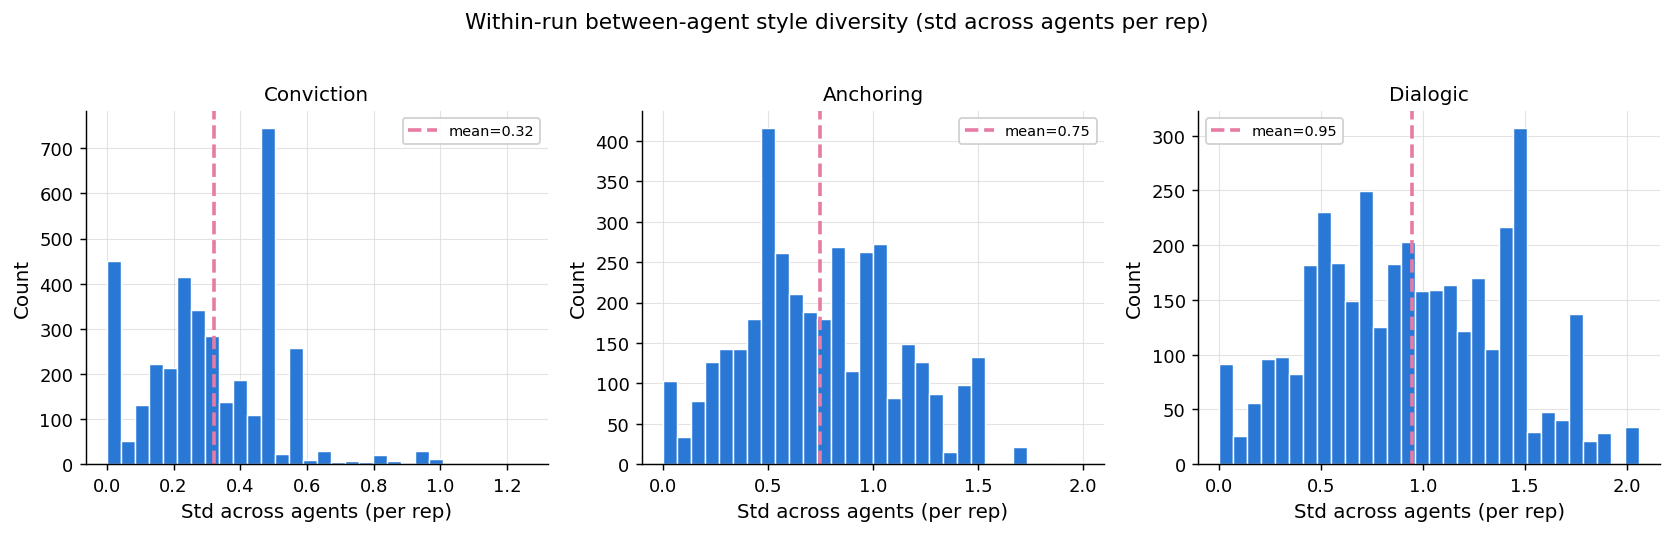

In [10]:
# Fig (inline only) — within-run std distributions, as in nb 028
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Within-run between-agent style diversity (std across agents per rep)', fontsize=12, y=1.02)
for ax, dim in zip(axes, DIMS):
    vals = within_rep[f'{dim}_std'].dropna()
    ax.hist(vals, bins=30, color='#2a78d6', edgecolor='white', linewidth=0.8)
    ax.axvline(vals.mean(), color='#e87ba4', linewidth=2, linestyle='--', label=f'mean={vals.mean():.2f}')
    ax.set_title(dim.capitalize(), fontsize=11)
    ax.set_xlabel('Std across agents (per rep)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Part 3 — Dataset level effects & hub-vs-leaf (star topology)

In [11]:
# Score / agent / system-level means by dataset
system_df = (ling_df.groupby(['dataset', 'topology', 'W', 'qid', 'rep_idx'])[DIMS]
             .mean().reset_index())
system_stats = system_df.groupby('dataset')[DIMS].agg(['mean', 'std'])

print('--- sec:results:linguistic L~1407 : system-level means, GPQA vs HiddenBench ---')
print('  thesis_says: conviction 3.55 vs 3.30 ; dialogic 3.01 vs 2.51')
for d in DIMS:
    g = system_stats.loc['gpqa', (d, 'mean')]
    h = system_stats.loc['hiddenbench', (d, 'mean')]
    print(f'  {d:11s} system-level  GPQA={g:.2f}  HiddenBench={h:.2f}')
conv_g = system_stats.loc['gpqa', ('conviction', 'mean')]
conv_h = system_stats.loc['hiddenbench', ('conviction', 'mean')]
dia_g  = system_stats.loc['gpqa', ('dialogic', 'mean')]
dia_h  = system_stats.loc['hiddenbench', ('dialogic', 'mean')]
print(f'  conviction GPQA={conv_g:.2f} (thesis 3.55) {"MATCH" if abs(conv_g-3.55)<0.05 else "MISMATCH"}  '
      f'HB={conv_h:.2f} (thesis 3.30) {"MATCH" if abs(conv_h-3.30)<0.05 else "MISMATCH"}')
print(f'  dialogic   GPQA={dia_g:.2f} (thesis 3.01) {"MATCH" if abs(dia_g-3.01)<0.05 else "MISMATCH"}  '
      f'HB={dia_h:.2f} (thesis 2.51) {"MATCH" if abs(dia_h-2.51)<0.05 else "MISMATCH"}')

--- sec:results:linguistic L~1407 : system-level means, GPQA vs HiddenBench ---
  thesis_says: conviction 3.55 vs 3.30 ; dialogic 3.01 vs 2.51
  conviction  system-level  GPQA=3.55  HiddenBench=3.30
  anchoring   system-level  GPQA=2.65  HiddenBench=2.12
  dialogic    system-level  GPQA=3.01  HiddenBench=2.51
  conviction GPQA=3.55 (thesis 3.55) MATCH  HB=3.30 (thesis 3.30) MATCH
  dialogic   GPQA=3.01 (thesis 3.01) MATCH  HB=2.51 (thesis 2.51) MATCH


In [12]:
# Hub vs leaf (star topology): agent 0 is hub, agents 1-3 leaves
star_ling = ling_df[ling_df['topology'] == 'star'].copy()
star_ling['role'] = star_ling['agent_idx'].apply(lambda x: 'hub' if x == 0 else 'leaf')

print('--- sec:results:linguistic L~1409 : hub vs leaf (star), MWU per dimension ---')
print('  thesis_says: conviction 3.44 vs 3.44 p=0.99 ; anchoring & dialogic small but significant |delta|<0.05')
for dim in DIMS:
    hub  = star_ling.loc[star_ling['role'] == 'hub', dim].dropna()
    leaf = star_ling.loc[star_ling['role'] == 'leaf', dim].dropna()
    u, p = stats.mannwhitneyu(hub, leaf, alternative='two-sided')
    print(f'  {dim:11s} hub={hub.mean():.2f}  leaf={leaf.mean():.2f}  '
          f'|delta|={abs(hub.mean()-leaf.mean()):.3f}  p={p:.4f}')

--- sec:results:linguistic L~1409 : hub vs leaf (star), MWU per dimension ---
  thesis_says: conviction 3.44 vs 3.44 p=0.99 ; anchoring & dialogic small but significant |delta|<0.05
  conviction  hub=3.44  leaf=3.44  |delta|=0.000  p=0.9861
  anchoring   hub=2.36  leaf=2.33  |delta|=0.032  p=0.0224
  dialogic    hub=2.89  leaf=2.84  |delta|=0.049  p=0.0034


---
## Part 4 — Kruskal-Wallis across bistability labels (null result)

In [13]:
labels_order = ['monostable', 'multistable', 'stochastic', 'insufficient']
present = [l for l in labels_order if l in merged['bis_label'].values]

print('--- sec:results:linguistic : linguistic dimensions by bistability label (Kruskal-Wallis) ---')
print(f'  labels present: {present}')
for dim in DIMS:
    groups = [merged.loc[merged['bis_label'] == l, dim].dropna().values for l in present]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        H, p = stats.kruskal(*groups)
        print(f'  {dim:11s}  H={H:.2f}  p={p:.4f}  {"(ns)" if p >= 0.05 else "(sig)"}')

--- sec:results:linguistic : linguistic dimensions by bistability label (Kruskal-Wallis) ---
  labels present: ['monostable', 'multistable', 'stochastic']
  conviction   H=12.29  p=0.0021  (sig)
  anchoring    H=4.60  p=0.1000  (ns)
  dialogic     H=3.05  p=0.2174  (ns)


---
## Part 5 — Method-section per-dimension distributions (`sec:method:linguistic`)

Per-dimension `describe()` and value_counts for the Mistral scorer (nb 027, 420 files, reps 0-4)
and the NLI DeBERTa scorer (nb 026v2, 221 files).

In [14]:
print('=== MISTRAL scorer (nb 027) — reps 0-4 ===')
mist_rows = []
for f in LING_DIR.glob('**/*.json'):
    mist_rows.extend(json.loads(f.read_text()))
mist = pd.DataFrame(mist_rows)
mist = mist[mist['rep_idx'] <= 4].reset_index(drop=True)
print(f'  rows (reps 0-4): {len(mist):,}  | topologies: {mist["topology"].value_counts().to_dict()}  | W: {sorted(mist["W"].unique())}')
print()
print('  --- describe() ---')
print(mist[DIMS].describe().round(2).to_string())
print()
for dim in DIMS:
    vc  = mist[dim].value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    print(f'  {dim} value_counts (n, %):')
    print(pd.DataFrame({'n': vc, '%': pct}).to_string())
    print()

=== MISTRAL scorer (nb 027) — reps 0-4 ===


  rows (reps 0-4): 30,760  | topologies: {'star': 17256, 'fc': 13504}  | W: [np.int64(1), np.int64(2), np.int64(5)]

  --- describe() ---
       conviction  anchoring  dialogic
count    30760.00   30760.00  30760.00
mean         3.42       2.39      2.77
std          0.53       1.12      1.34
min          2.00       1.00      1.00
25%          3.00       1.00      2.00
50%          3.00       3.00      3.00
75%          4.00       3.00      4.00
max          5.00       5.00      5.00

  conviction value_counts (n, %):
                n     %
conviction             
2              59   0.2
3           18104  58.9
4           12068  39.2
5             529   1.7

  anchoring value_counts (n, %):
               n     %
anchoring             
1          10263  33.4
2           3557  11.6
3          11581  37.6
4           5334  17.3
5             25   0.1

  dialogic value_counts (n, %):
              n     %
dialogic             
1          7630  24.8
2          7577  24.6
3          1632 

In [15]:
print('=== NLI DeBERTa scorer (nb 026v2) ===')
nli_rows = []
for f in LING_NLI.glob('**/*.json'):
    nli_rows.extend(json.loads(f.read_text()))
nli = pd.DataFrame(nli_rows)
print(f'  files: {len(list(LING_NLI.glob("**/*.json")))}   thesis_says=221   '
      f'{"MATCH" if len(list(LING_NLI.glob("**/*.json")))==221 else "MISMATCH"}')
print(f'  rows: {len(nli):,}  | topologies: {nli["topology"].value_counts().to_dict()}')
print()
print('  --- describe() ---')
print(nli[DIMS].describe().round(2).to_string())
print()
for dim in DIMS:
    vc  = nli[dim].value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    print(f'  {dim} value_counts (n, %):')
    print(pd.DataFrame({'n': vc, '%': pct}).to_string())
    print()

=== NLI DeBERTa scorer (nb 026v2) ===


  files: 221   thesis_says=221   MATCH
  rows: 119,464  | topologies: {'fc': 70772, 'star': 48692}

  --- describe() ---
       conviction  anchoring   dialogic
count   119464.00  119464.00  119464.00
mean         3.79       3.61       4.33
std          1.05       0.78       1.05
min          1.00       1.00       1.00
25%          4.00       4.00       4.00
50%          4.00       4.00       5.00
75%          4.00       4.00       5.00
max          5.00       5.00       5.00

  conviction value_counts (n, %):
                n     %
conviction             
1            3345   2.8
2           19086  16.0
3            2902   2.4
4           67845  56.8
5           26286  22.0

  anchoring value_counts (n, %):
               n     %
anchoring             
1            220   0.2
2          21016  17.6
3           4291   3.6
4          93827  78.5
5            110   0.1

  dialogic value_counts (n, %):
              n     %
dialogic             
1          1421   1.2
2         12273  10.3
